In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/creditcard.csv')
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [8]:
print("jumlah baris dan kolom:", df.shape)
print("\ninfo tipe data: ")
print(df.info())

jumlah baris dan kolom: (284807, 31)

info tipe data: 
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20 

In [9]:
jumlah_per_kelas = df['Class'].value_counts()
print(jumlah_per_kelas)

Class
0    284315
1       492
Name: count, dtype: int64


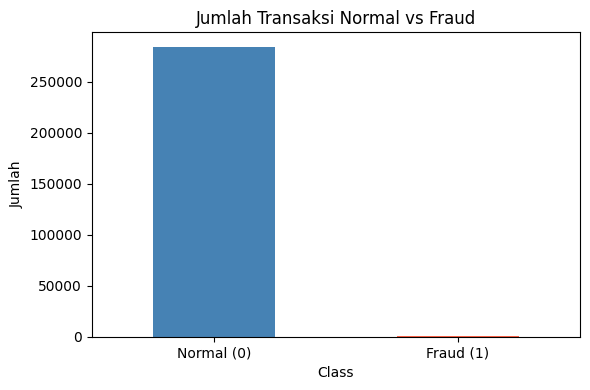


Persentase fraud: 0.1727%


In [10]:
plt.figure(figsize=(6, 4))
jumlah_per_kelas.plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Jumlah Transaksi Normal vs Fraud')
plt.xticks([0, 1], ['Normal (0)', 'Fraud (1)'], rotation=0)
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

print(f"\nPersentase fraud: {jumlah_per_kelas[1] / len(df) * 100:.4f}%")

In [11]:
# df.describe() = "Kasih saya ringkasan statistik semua kolom angka"
# Seperti laporan: nilai minimum, maksimum, rata-rata, dll
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00  1.332271e+00  1.23709

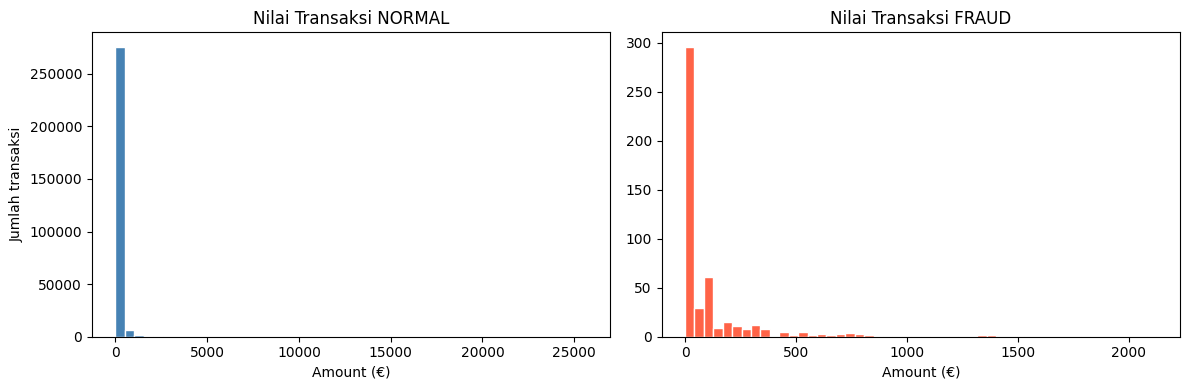

Rata-rata transaksi NORMAL : €88.29
Rata-rata transaksi FRAUD  : €122.21


In [12]:
# Pisahkan data fraud dan normal dulu
# df[df['Class'] == 0] artinya: "Ambil semua baris dimana Class = 0 (normal)"
# df[df['Class'] == 1] artinya: "Ambil semua baris dimana Class = 1 (fraud)"
normal = df[df['Class'] == 0]['Amount']
fraud  = df[df['Class'] == 1]['Amount']

# Buat grafik berdampingan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Grafik kiri: distribusi nominal transaksi normal
axes[0].hist(normal, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Nilai Transaksi NORMAL')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Jumlah transaksi')

# Grafik kanan: distribusi nominal transaksi fraud
axes[1].hist(fraud, bins=50, color='tomato', edgecolor='white')
axes[1].set_title('Nilai Transaksi FRAUD')
axes[1].set_xlabel('Amount (€)')

plt.tight_layout()
plt.show()

# Cetak rata-rata keduanya untuk perbandingan
print(f"Rata-rata transaksi NORMAL : €{normal.mean():.2f}")
print(f"Rata-rata transaksi FRAUD  : €{fraud.mean():.2f}")

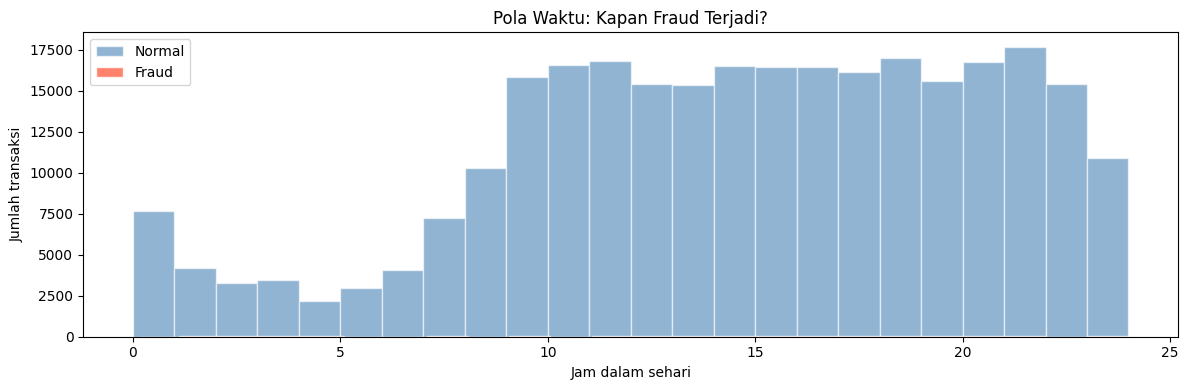

In [13]:
# Kolom "Time" isinya detik sejak transaksi pertama
# Kita konversi ke jam supaya lebih mudah dibaca
df['Hour'] = (df['Time'] / 3600) % 24

# Pisahkan lagi berdasarkan kelas
normal_hour = df[df['Class'] == 0]['Hour']
fraud_hour  = df[df['Class'] == 1]['Hour']

plt.figure(figsize=(12, 4))
plt.hist(normal_hour, bins=24, alpha=0.6, color='steelblue', label='Normal', edgecolor='white')
plt.hist(fraud_hour,  bins=24, alpha=0.8, color='tomato',    label='Fraud',  edgecolor='white')
plt.xlabel('Jam dalam sehari')
plt.ylabel('Jumlah transaksi')
plt.title('Pola Waktu: Kapan Fraud Terjadi?')
plt.legend()
plt.tight_layout()
plt.show()

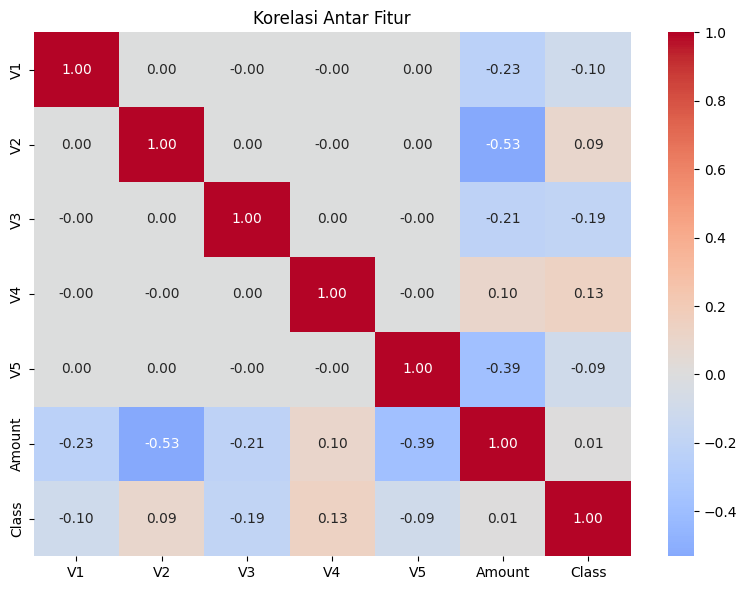

In [14]:
# Pilih beberapa kolom saja supaya heatmap tidak terlalu penuh
cols = ['V1','V2','V3','V4','V5','Amount','Class']

# corr() = hitung seberapa "berhubungan" antar kolom
# Nilainya -1 sampai 1:
#   1  = kalau A naik, B pasti naik juga
#  -1  = kalau A naik, B pasti turun
#   0  = tidak ada hubungan sama sekali
korelasi = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    korelasi,
    annot=True,      # tampilkan angkanya
    fmt='.2f',       # format 2 desimal
    cmap='coolwarm', # warna: biru = negatif, merah = positif
    center=0
)
plt.title('Korelasi Antar Fitur')
plt.tight_layout()
plt.show()